In [1]:
import pandas as pd

df = pd.read_csv("milknew.csv")

print(df.head())

    pH  Temprature  Taste  Odor  Fat   Turbidity  Colour   Grade
0  6.6          35      1     0     1          0     254    high
1  6.6          36      0     1     0          1     253    high
2  8.5          70      1     1     1          1     246     low
3  9.5          34      1     1     0          1     255     low
4  6.6          37      0     0     0          0     255  medium


In [2]:
# Hiển thị số dòng và số cột của dataset
print(df.shape)

(1059, 8)


In [3]:
print(df.dtypes)

pH            float64
Temprature      int64
Taste           int64
Odor            int64
Fat             int64
Turbidity       int64
Colour          int64
Grade          object
dtype: object


In [4]:
print(df.describe())

                pH   Temprature        Taste         Odor         Fat   \
count  1059.000000  1059.000000  1059.000000  1059.000000  1059.000000   
mean      6.630123    44.226629     0.546742     0.432483     0.671388   
std       1.399679    10.098364     0.498046     0.495655     0.469930   
min       3.000000    34.000000     0.000000     0.000000     0.000000   
25%       6.500000    38.000000     0.000000     0.000000     0.000000   
50%       6.700000    41.000000     1.000000     0.000000     1.000000   
75%       6.800000    45.000000     1.000000     1.000000     1.000000   
max       9.500000    90.000000     1.000000     1.000000     1.000000   

         Turbidity       Colour  
count  1059.000000  1059.000000  
mean      0.491029   251.840415  
std       0.500156     4.307424  
min       0.000000   240.000000  
25%       0.000000   250.000000  
50%       0.000000   255.000000  
75%       1.000000   255.000000  
max       1.000000   255.000000  


In [5]:
# Kiểm tra dữ liệu thiếu trước khi xử lý
print("Missing Values trước xử lý:")
print(df.isnull().sum())

# Điền giá trị thiếu bằng median
df.fillna(df.median(numeric_only=True), inplace=True)

# Kiểm tra lại sau xử lý
print("\nMissing Values sau xử lý:")
print(df.isnull().sum())

Missing Values trước xử lý:
pH            0
Temprature    0
Taste         0
Odor          0
Fat           0
Turbidity     0
Colour        0
Grade         0
dtype: int64

Missing Values sau xử lý:
pH            0
Temprature    0
Taste         0
Odor          0
Fat           0
Turbidity     0
Colour        0
Grade         0
dtype: int64


In [6]:
# Số dòng trùng lặp
# Dataset có 976 bản ghi trùng về mặt thuộc tính.
# Tuy nhiên các bản ghi này có thể đại diện cho nhiều mẫu sữa khác nhau nên không loại bỏ để tránh làm mất dữ liệu huấn luyện.
print("Duplicate trước xử lý:")
print(df.duplicated().sum())

Duplicate trước xử lý:
976


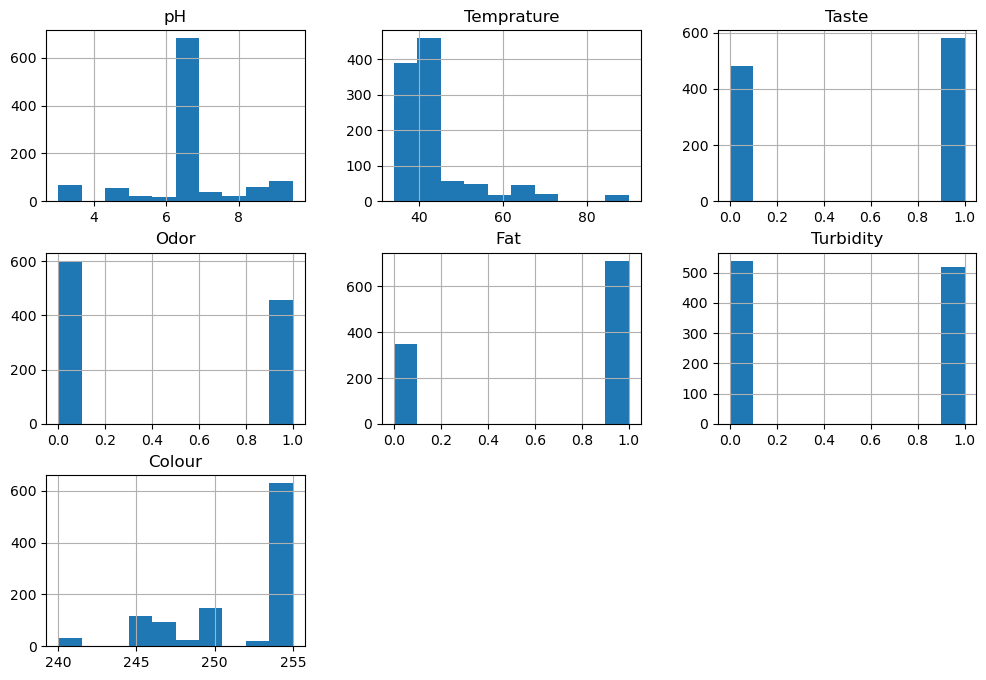

In [7]:
### Trực quan hóa dữ liệu
# Histogram
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

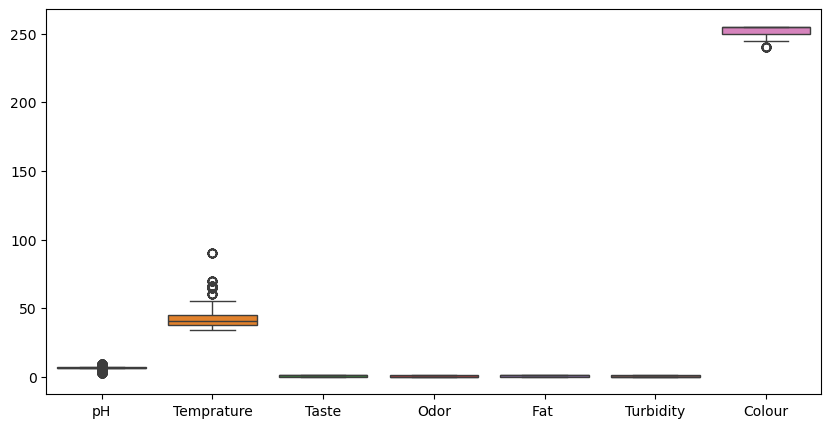

In [8]:
# Boxplot phát hiện Outlier
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

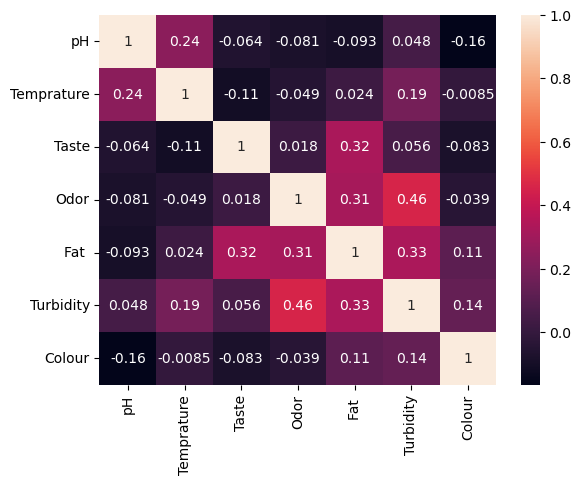

In [9]:
# Heatmap
sns.heatmap(df.corr(numeric_only=True),
            annot=True)
plt.show()

In [10]:
# Chuyển dữ liệu dạng chữ thành số

grade_map = {
    "low": 0,
    "medium": 1,
    "high": 2
}

df["Grade"] = df["Grade"].map(grade_map)

print("Mapping:")
for key, value in grade_map.items():
    print(f"{key} -> {value}")

Mapping:
low -> 0
medium -> 1
high -> 2


In [11]:
X = df.drop("Grade", axis=1)

y = df["Grade"]

In [12]:
#chuẩn hóa dữ liệu (Feature Scaling) bằng StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print(scaled_df.head())

         pH  Temprature     Taste      Odor      Fat   Turbidity    Colour
0 -0.021531   -0.914107  0.910503 -0.872962  0.699608  -0.982217  0.501600
1 -0.021531   -0.815035 -1.098294  1.145525 -1.429372   1.018105  0.269333
2  1.336564    2.553438  0.910503  1.145525  0.699608   1.018105 -1.356536
3  2.051351   -1.013180  0.910503  1.145525 -1.429372   1.018105  0.733867
4 -0.021531   -0.715962 -1.098294 -0.872962 -1.429372  -0.982217  0.733867


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)
print("Train:", X_train.shape)
print("Test :", X_test.shape)
model.fit(X_train, y_train)

Train: (847, 7)
Test : (212, 7)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.9952830188679245

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        78
           1       1.00      1.00      1.00        86
           2       0.98      1.00      0.99        48

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212


Confusion Matrix:
[[77  0  1]
 [ 0 86  0]
 [ 0  0 48]]


In [16]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_scaled,
    y,
    cv=5
)

print(scores)
print(scores.mean())

[0.99056604 1.         1.         1.         0.99052133]
0.9962174729500134


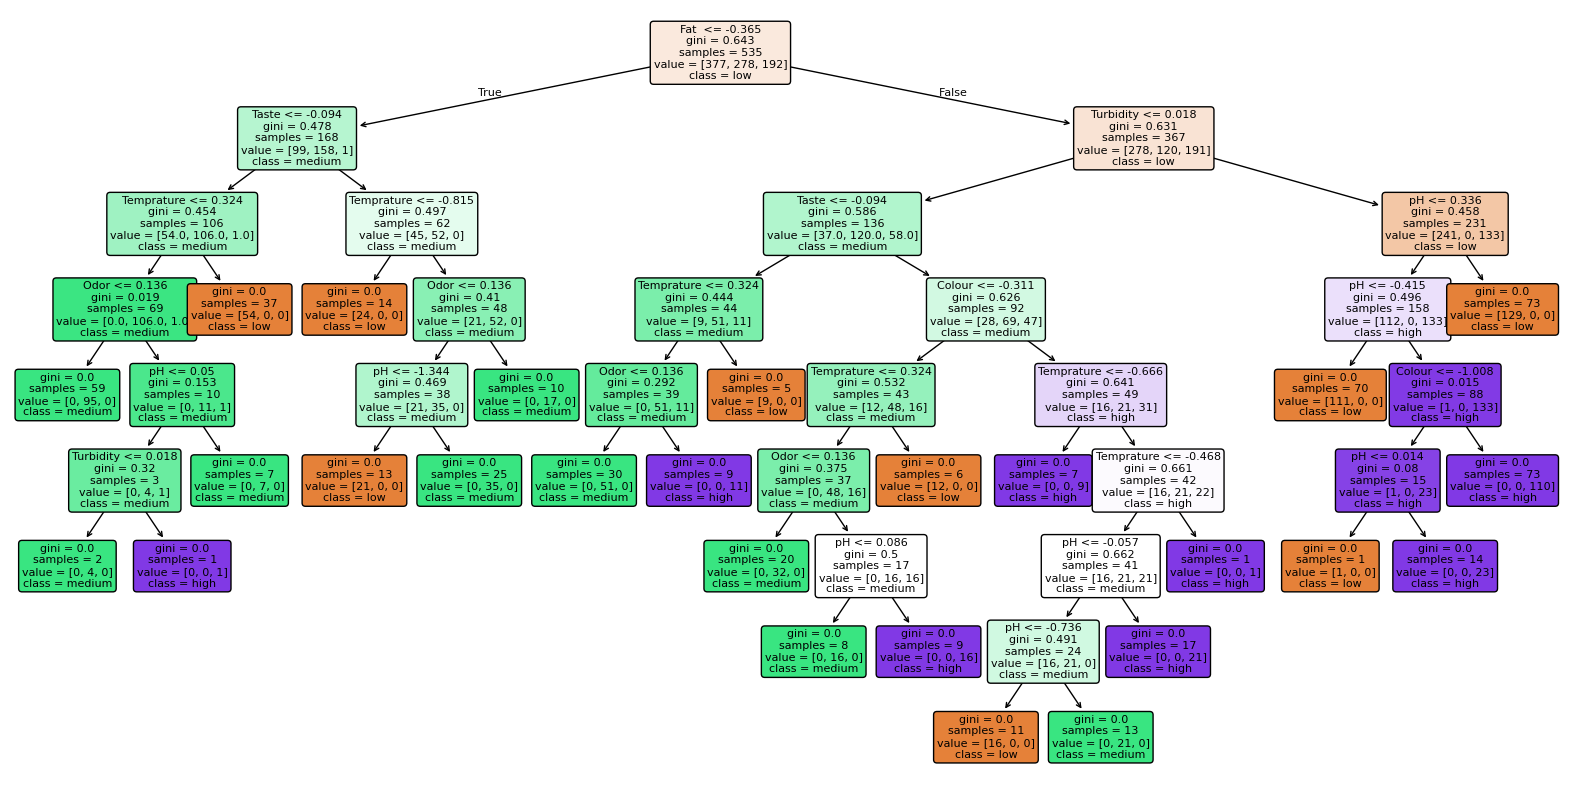

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Lấy cây đầu tiên trong rừng
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["low", "medium", "high"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = model.estimators_[0]

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["low", "medium", "high"],
    filled=True,
    rounded=True
)

plt.savefig("random_forest_tree.png", dpi=300)
plt.close()

In [20]:
from sklearn.tree import export_graphviz
import graphviz

tree = model.estimators_[0]

dot_data = export_graphviz(
    tree,
    out_file=None,
    feature_names=X.columns,
    class_names=["low", "medium", "high"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)

graph.render("milk_tree", format="png")

ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH